# Hilbert Curve

## What is a Space-Filling Curve?

A **space-filling curve** is a continuous curve that passes through every point of a higher-dimensional region (e.g., the unit square $[0,1]^2$). The existence of such curves — proved by Peano in 1890 — was a profound surprise, since it implies a **bijection** between $[0,1]$ and $[0,1]^2$, contradicting naive dimension intuitions.

The **Hilbert curve**, introduced by David Hilbert in 1891, is the most celebrated example. It is constructed recursively: at order $n$, the square is divided into $4^n$ sub-squares, each visited exactly once. As $n \to \infty$, the limit curve is continuous (but nowhere differentiable) and truly fills the square.

## Recursive Construction

The order-$n$ Hilbert curve $H_n : [0, 4^n-1] \to [0,1]^2$ is built from four rotated/reflected copies of $H_{n-1}$:

$$H_n = \begin{cases}
\text{SW}: & \text{reflect } H_{n-1} \text{ along diagonal} \\
\text{NW}: & H_{n-1} \text{ (unchanged)} \\
\text{NE}: & H_{n-1} \text{ (unchanged)} \\
\text{SE}: & \text{reflect and rotate } H_{n-1}
\end{cases}$$

At order $n$, the curve visits $4^n$ points on a $2^n \times 2^n$ grid.

## Why Is It Useful?

- **Locality**: nearby points on the curve tend to be nearby in the plane. This makes the Hilbert curve valuable for **cache-efficient memory layout**, **spatial databases** (R-trees), and **image processing**.
- **Fractal dimension**: $d_f = 2$, filling the plane completely.
- **Artistic / educational**: the colored traversal reveals the fractal self-similar structure beautifully.

### Environment setup

We use only NumPy and Matplotlib — no external dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from ipywidgets import interact, IntSlider

### Recursive Hilbert curve generator

The function below implements the standard recursive construction. At level $n=0$, the curve is just the origin. For $n \geq 1$, the four quadrant copies are assembled with the appropriate reflections:

$$H_n(t) = \begin{cases} (y, x)/2 & t \in [0, 4^{n-1}) \text{ (SW, diagonal reflect)} \\ (x, y+1)/2 & t \in [4^{n-1}, 2 \cdot 4^{n-1}) \text{ (NW)} \\ (x+1, y+1)/2 & t \in [2 \cdot 4^{n-1}, 3 \cdot 4^{n-1}) \text{ (NE)} \\ (1-y, 1-x+1)/2 & t \in [3 \cdot 4^{n-1}, 4^n) \text{ (SE, anti-diagonal reflect)} \end{cases}$$

In [2]:
def hilbert_curve(n):
    """Return (x, y) arrays of the order-n Hilbert curve, normalized to [0,1]^2."""
    if n <= 0:
        return np.array([0.0]), np.array([0.0])
    xo, yo = hilbert_curve(n - 1)
    # Four quadrant copies with appropriate reflections
    x = 0.5 * np.concatenate([ -0.5 + yo,  -0.5 + xo,   0.5 + xo,   0.5 - yo])
    y = 0.5 * np.concatenate([ -0.5 + xo,   0.5 + yo,   0.5 + yo,  -0.5 - xo])
    return x, y

### Multi-order visualization

We display Hilbert curves of orders $n = 1, \ldots, 6$ side by side. Each segment is colored along the traversal using a blue-to-red colormap, revealing the self-similar recursive structure.

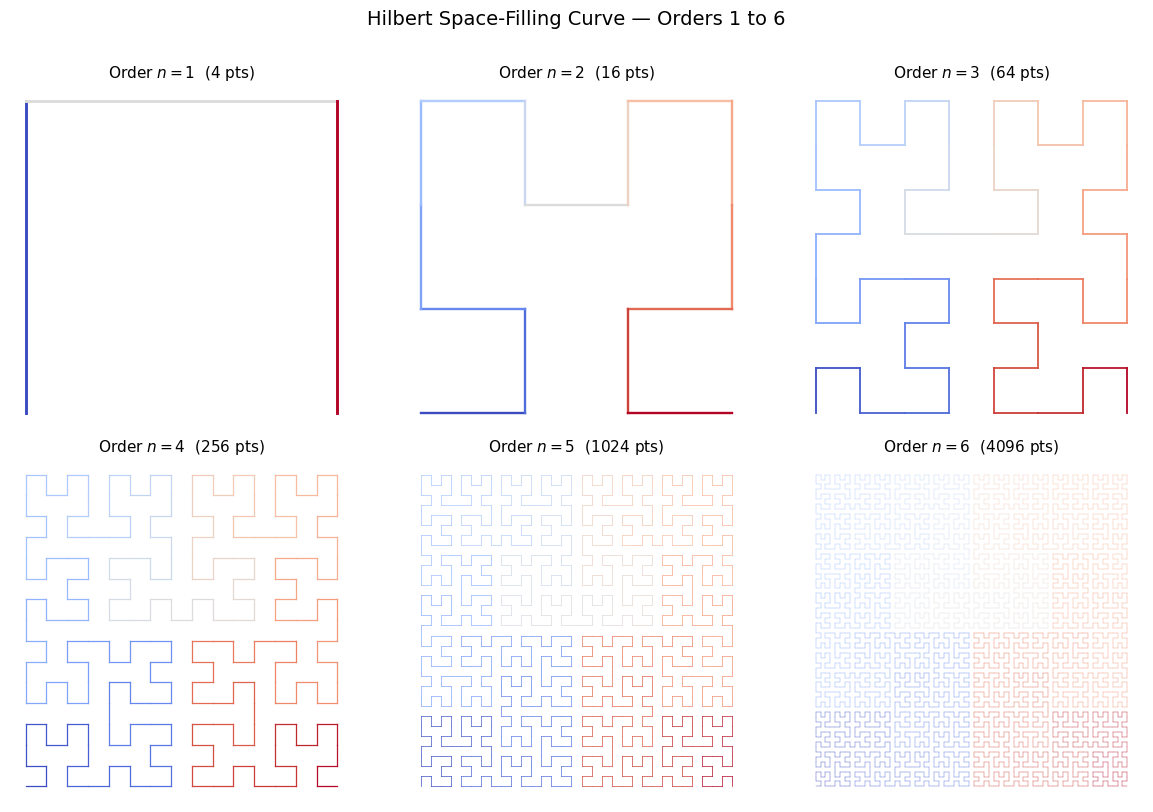

In [3]:
orders = [1, 2, 3, 4, 5, 6]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for ax, n in zip(axes, orders):
    x, y = hilbert_curve(n)
    k = len(x)
    colors = cm.coolwarm(np.linspace(0, 1, k - 1))
    for i in range(k - 1):
        ax.plot(x[i:i+2], y[i:i+2], color=colors[i], linewidth=max(0.3, 2.5 - 0.4*n))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Order $n={n}$  ({k} pts)', fontsize=11)

plt.suptitle('Hilbert Space-Filling Curve — Orders 1 to 6', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('hilbert_orders.png', dpi=120, bbox_inches='tight')
plt.show()

### Locality-preserving property

The Hilbert curve is often used in practice because **nearby indices on the 1D curve map to nearby points in 2D**. We can visualize this by coloring the $2^n \times 2^n$ grid cells by their 1D index — a spatially coherent coloring indicates high locality.

The *index map* assigns to each grid cell $(i,j)$ the time $t$ at which the curve visits it:
$$\text{index}(i,j) = H_n^{-1}(i/(2^n-1), j/(2^n-1))$$

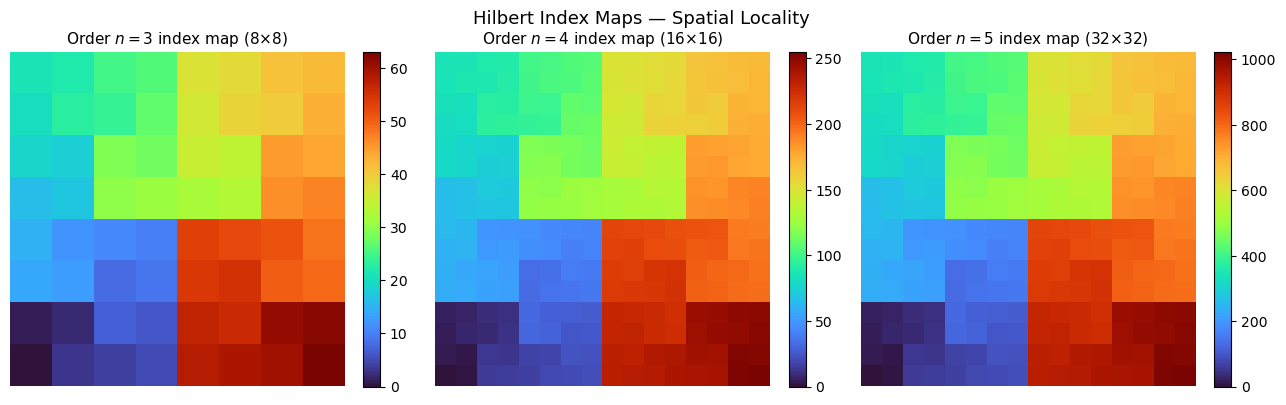

In [4]:
def hilbert_index_map(n):
    """Build the 2^n x 2^n grid of Hilbert traversal indices."""
    x, y = hilbert_curve(n)
    size = 2**n
    # Map coordinates in [-0.5, 0.5] -> grid indices [0, size-1]
    ix = np.round((x + 0.5) * (size - 1)).astype(int)
    iy = np.round((y + 0.5) * (size - 1)).astype(int)
    grid = np.zeros((size, size))
    for t, (ci, cj) in enumerate(zip(ix, iy)):
        grid[cj, ci] = t
    return grid

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, n in zip(axes, [3, 4, 5]):
    grid = hilbert_index_map(n)
    im = ax.imshow(grid, cmap='turbo', origin='lower')
    ax.set_title(f'Order $n={n}$ index map ({2**n}×{2**n})', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Hilbert Index Maps — Spatial Locality', fontsize=13)
plt.tight_layout()
plt.savefig('hilbert_index.png', dpi=120, bbox_inches='tight')
plt.show()

### Interactive exploration

Use the slider to explore different orders of the Hilbert curve. The coloring maps traversal time to a hue, making the recursive structure vivid.

In [ ]:
def plot_hilbert(order=4):
    x, y = hilbert_curve(order)
    k = len(x)
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = cm.plasma(np.linspace(0, 1, k - 1))
    lw = max(0.2, 3.0 - 0.45 * order)
    for i in range(k - 1):
        ax.plot(x[i:i+2], y[i:i+2], color=colors[i], linewidth=lw)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'Hilbert Curve — Order {order}  ({k} nodes)', fontsize=13)
    plt.tight_layout(); plt.show()

interact(plot_hilbert, order=IntSlider(min=1, max=7, step=1, value=4));

### Snippet image

Static rendering for a representative figure.

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    import matplotlib.cm as _cm

    fig, axes = _plt.subplots(2, 3, figsize=(9, 6))
    axes = axes.ravel()
    for ax, n in zip(axes, [1,2,3,4,5,6]):
        x, y = hilbert_curve(n)
        k = len(x)
        colors = _cm.plasma(np.linspace(0, 1, k - 1))
        lw = max(0.2, 2.5 - 0.4*n)
        for i in range(k - 1):
            ax.plot(x[i:i+2], y[i:i+2], color=colors[i], linewidth=lw)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(f'n={n}', fontsize=10)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The Hilbert curve is a **continuous, nowhere differentiable surjection** from $[0,1]$ onto $[0,1]^2$.
- Its **recursive structure** makes it easy to implement and to reason about.
- The key practical property is **locality**: $|H_n(s) - H_n(t)|_2$ is small when $|s - t|$ is small, making it ideal for spatial indexing and cache-friendly data layouts.
- The fractal dimension equals the ambient dimension ($d_f = 2$), confirming it is a true space-filler.

## Bibliography

- D. Hilbert, *Über die stetige Abbildung einer Linie auf ein Flächenstück*, Math. Ann. 38, 1891.
- H. Sagan, *Space-Filling Curves*, Springer, 1994.
- C. Faloutsos & S. Roseman, *Fractals for secondary key retrieval*, PODS 1989.